# 라이브러리

In [158]:
from imports import *
%reload_ext autoreload
%autoreload 2

# 데이터셋

In [2]:
# 데이터 불러오기
df = pd.read_excel('./dataset/oecd_dataset.xlsx', index_col='Reference area')
# 결측을 제외한 183개 국가만 선택
df = df[df.notnull().all(axis=1)]

In [40]:
df.round(1)

,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
Reference area,,,,,,,,,,,,
Australia,11860732.7,12063021.4,12455751.1,13723725.9,14701734.3,15461977.2,14738096.5,6112265.9,3984941.1,7525983.5,11298137.3,12870576.0
Austria,2032032.3,2138526.6,2219886.6,2289076.6,2294330.9,2556748.9,2966439.4,1041594.6,1240233.6,2078696.9,2469198.6,2682274.5
Belgium,3247814.2,3195722.8,3413040.5,3466534.3,3672222.0,3940235.8,4039798.5,2236333.8,3240717.6,3894086.3,3766052.1,3930514.0
Canada,9517376.7,10106189.4,10706255.2,11606782.6,12420954.4,13083421.6,13824361.0,5671979.1,5128085.8,9490621.0,11469309.5,12787228.3
Chile,1645285.3,1679696.5,1833572.8,1939507.5,2081471.4,2191711.5,2235390.1,1207357.4,1204832.9,1717065.8,1965011.6,2204970.0
...,...,...,...,...,...,...,...,...,...,...,...,...
Vanuatu,29525.4,26833.0,24494.2,22117.6,24196.7,28061.3,25512.0,5878.3,3157.2,11358.0,22313.9,11515.7
Venezuela,991198.7,715855.8,603853.4,573210.9,434663.1,400566.1,313361.9,74626.3,104650.5,193219.5,278163.1,245325.9
Viet Nam,2142564.9,2305220.9,2567449.5,3019055.6,3616451.4,4230438.4,4941541.3,1822487.4,1497054.1,2383585.2,4106124.5,3527683.0


In [41]:
df_num = df.copy()
df_num = np.log(df_num) #[years])  # 로그 변환

# 연도별 로그 성장률
growth = df_num.diff(axis=1).iloc[:, 1:]  # 2014~2024
display(growth)
print('''
연도별 로그 성장률을 도출하였다.
2019년의 코로나 충격이 2020년 성장률에 영향을 미쳐 -1.46 로그 성장률이 도출된다.
''')

,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
Reference area,,,,,,,,,,,
Australia,0.016912,0.032038,0.096944,0.068839,0.050418,-0.047948,-0.880138,-0.427775,0.635839,0.406276,0.130306
Austria,0.051081,0.037339,0.030692,0.002293,0.108295,0.148626,-1.046610,0.174547,0.516441,0.172152,0.082771
Belgium,-0.016169,0.065790,0.015552,0.057642,0.070444,0.024954,-0.591357,0.370957,0.183664,-0.033432,0.042743
Canada,0.060029,0.057680,0.080761,0.067795,0.051961,0.055086,-0.890894,-0.100806,0.615572,0.189371,0.108772
Chile,0.020699,0.087653,0.056168,0.070641,0.051608,0.019733,-0.615982,-0.002093,0.354276,0.134881,0.115216
...,...,...,...,...,...,...,...,...,...,...,...
Vanuatu,-0.095619,-0.091196,-0.102060,0.089843,0.148172,-0.095241,-1.467890,-0.621560,1.280222,0.675291,-0.661496
Venezuela,-0.325436,-0.170147,-0.052078,-0.276682,-0.081692,-0.245520,-1.434865,0.338132,0.613201,0.364381,-0.125620
Viet Nam,0.073173,0.107736,0.162031,0.180549,0.156812,0.155372,-0.997475,-0.196703,0.465106,0.543874,-0.151838



연도별 로그 성장률을 도출하였다.
2019년의 코로나 충격이 2020년 성장률에 영향을 미쳐 -1.46 로그 성장률이 도출된다.



In [44]:
e_hist = df.sum().to_numpy()

array([4.37964526e+08, 4.60737641e+08, 4.87061572e+08, 5.11497409e+08,
       5.39337952e+08, 5.66556710e+08, 5.85262121e+08, 2.52551012e+08,
       2.73064792e+08, 3.98042307e+08, 4.92038938e+08, 5.46034447e+08])

# 시나리오

In [6]:
# 9개 시나리오 도출
## 평균 성장률 낮음 3%, 중간 5%, 높음 7%
## 변동성 낮음 10%, 중간 20%, 높음 30%
## 3 x 3 = 9개

scenarios = []
for growth_rate in [0.03, 0.05, 0.07]:
    for volatility in [0.1, 0.2, 0.3]:
        scenarios.append((growth_rate, volatility))
scenarios_df = pd.DataFrame(scenarios, columns=['growth_rate', 'volatility'])
scenarios_df['growth_level'] = scenarios_df['growth_rate'].map({    0.03: 'L',    0.05: 'M',    0.07: 'H'})
scenarios_df['volatility_level'] = scenarios_df['volatility'].map({    0.1: 'l',    0.2: 'm',    0.3: 'h'})
scenarios_df['scenario'] = (
    'G' + scenarios_df['growth_level'] +
    '_V' + scenarios_df['volatility_level']
)
# scenarios_df = scenarios_df[['scenario', 'growth_rate', 'volatility']]
scenarios_df

,growth_rate,volatility,growth_level,volatility_level,scenario
0,0.03,0.1,L,l,GL_Vl
1,0.03,0.2,L,m,GL_Vm
2,0.03,0.3,L,h,GL_Vh
3,0.05,0.1,M,l,GM_Vl
4,0.05,0.2,M,m,GM_Vm
5,0.05,0.3,M,h,GM_Vh
6,0.07,0.1,H,l,GH_Vl
7,0.07,0.2,H,m,GH_Vm
8,0.07,0.3,H,h,GH_Vh


## 변수설정


In [62]:
# 배출량 한도 2019 emission cap 
cap = df[2019]
# 2024년 가격 2024 baseline
e0 = df[2024]
# carbon price probability distribution assumption
## based on eu-ETS historical data
## price u = 75, std = 7
carbon = {'mu': 75, 'std': 7}

In [64]:
e0 = e0.to_numpy()
e0 = e0[:, None, None, None]  # (183, 1, 1, 1)
e0.shape

(183, 1, 1, 1)

# 차원

In [ ]:
country = 183
period = 26   # 2024~2050
n_simulation = 10_0   # 시뮬레이션 수

# 시나리오
means = np.array(scenarios_df['growth_rate'])
stds = np.array(scenarios_df['volatility'])
# 이것도 가능
# # means = np.array([3, 5, 7])
# # stds  = np.array([10, 20, 30])
# # scenario_means = np.repeat(means, len(stds))   # [3,3,3,5,5,5,7,7,7]
# # scenario_stds  = np.tile(stds, len(means))     # [10,20,30,10,20,30,10,20,30]


# 성장 시나리오

In [ ]:
# 성장률 난수 생성
rng = np.random.default_rng(42)
X_rng = rng.normal(
    loc=means,
    scale=stds,
    size=(country, period, n_simulation, len(means))
)
print(X_rng.shape)
np.save('./scenario_result/X_rng_simple.npy', X_rng)

In [ ]:
# 누적 성장률과 연도별 누적 배출량
X_cumsum = np.cumsum(X_rng, axis=1)  # 누적합
X_emission = e0 * np.exp(X_cumsum)

In [68]:
# 과거 데이터 붙이기(2013~2024)
e_history = df.sum().to_numpy()
e0_global = e_history[-1]
g_history = e_history / e0_global
# g_history = g_history[:, None, None, None]  # (1, 12, 1, 1)
g_history.shape

(12,)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# years
years_hist = np.arange(2013, 2025)   # df 컬럼에 맞게 조정
years_sim  = np.arange(2025, 2051)

years = np.arange(2025, 2051)  # period=26 가정
assert len(years) == X_emission.shape[1]

# 전세계 baseline (E0 합)
E0_global = e0.reshape(-1).sum()  # e0가 (183,1,1,1)면 reshape로 1D

# 전세계 총배출량: 국가축 합
# (time, sim, scenario)
E_global = X_emission.sum(axis=0)

# 전세계 성장계수: E/E0
# (time, sim, scenario)
G = E_global / E0_global


In [ ]:
# 시나리오 3*3개
means = [0.03, 0.05, 0.07]   # 3%,5%,7%
stds  = [0.10, 0.20, 0.30]   # 10%,20%,30%

# G의 scenario 축(마지막 축)이 9개여야 함
# 시나리오 인덱스 매핑: (mu_idx, std_idx) -> k
# k = mu_idx*3 + std_idx  ( (3,10),(3,20),(3,30),(5,10)... )
def scen_idx(i_mu, j_std):
    return i_mu * len(stds) + j_std

q_low, q_high = 0.10, 0.90  # 10~90% 밴드 (원하면 0.05~0.95로 바꿔도 됨)


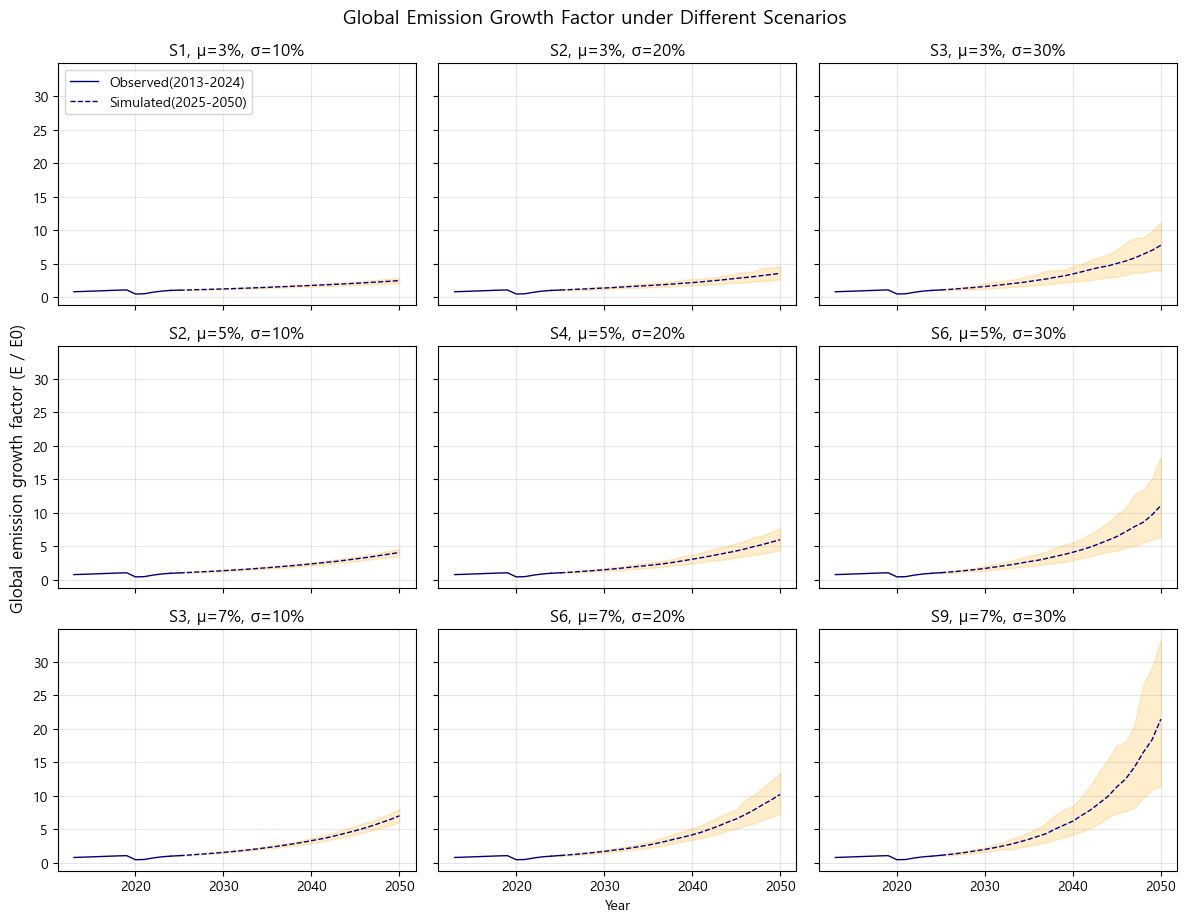

In [171]:
# 차트 그리기
fig, axes = plt.subplots(len(means), len(stds), figsize=(12, 9), sharex=True, sharey=True)

for i, mu in enumerate(means):
    for j, sd in enumerate(stds):
        ax = axes[i, j]
        k = scen_idx(i, j)

        # (time, sim)
        g_ts = G[:, :, k]

        # 연도별 요약 (time,)
        g_mean = g_ts.mean(axis=1)
        g_lo   = np.quantile(g_ts, q_low,  axis=1)
        g_hi   = np.quantile(g_ts, q_high, axis=1)

        # ① 과거 (실측)
        ax.plot(
            years_hist,
            g_history,
            color="Navy",
            label="Observed(2013-2024)"
            , linewidth=1
        )
        ax.plot(
            [2024, 2025],
            [g_history[-1], g_mean[0]],
            color="Navy", linewidth=1
        )
        # 평균선 + 밴드
        ax.plot(years_sim, g_mean, color="Navy", 
            label="Simulated(2025-2050)", linestyle='--', linewidth=1)
        ax.fill_between(years_sim, g_lo, g_hi, color='orange', alpha=0.2)

        ax.set_title(f"S{(i+1)*(j+1)}, μ={int(mu*100)}%, σ={int(sd*100)}%")
        ax.grid(True, alpha=0.3)
axes[-1, 1].set_xlabel("Year")
axes[1, 0].set_ylabel("Global emission growth factor (E / E0)", fontsize=12)
axes[0, 0].legend(loc="upper left", frameon=True)
plt.tight_layout()
fig.suptitle(
    "Global Emission Growth Factor under Different Scenarios",
    fontsize=14, y=1.02)
plt.show()


In [172]:
import numpy as np
import pandas as pd

# ===== 설정 =====
q_list = [0.10, 0.25, 0.75, 0.90]  # P10, Q1, Q3, P90
year_target = 2050

# years_sim이 예: [2025, 2026, ..., 2050] 라고 가정
# 혹시 years_sim이 numpy array든 list든 상관없음
try:
    t_idx = list(years_sim).index(year_target)
except ValueError:
    raise ValueError(f"{year_target}년이 years_sim에 없습니다. years_sim={years_sim[:5]}...")

rows = []

for i, mu in enumerate(means):
    for j, sd in enumerate(stds):
        k = scen_idx(i, j)

        # (time, sim) for scenario k
        g_ts = G[:, :, k]

        # ===== 2025년 단면: (sim,) =====
        x = g_ts[t_idx, :]

        p10, q1, q3, p90 = np.quantile(x, q_list)
        mean_ = x.mean()

        rows.append({
            "Scenario": f"S{k+1}",      # 시나리오 번호(0-based -> 1-based)
            "mu": mu,                   # 0.03 같은 값
            "sigma": sd,                # 0.10 같은 값
            "Year": year_target,
            "P10": p10,
            "Q1": q1,
            "Mean": mean_,
            "Q3": q3,
            "P90": p90,
        })

df_2025 = pd.DataFrame(rows)

# 보기 좋게 정렬(μ, σ 기준)
df_2025 = df_2025.sort_values(["mu", "sigma"]).reset_index(drop=True)

# 퍼센트 표시용(선택): 성장계수(E/E0) 그대로 두는 게 기본이고,
# %로 바꾸고 싶으면 (x-1)*100 형태를 별도 컬럼으로 만들면 됨.
display('2050년 기준 성장계수(E/E0) 분포 요약:')
display(df_2025)


'2050년 기준 성장계수(E/E0) 분포 요약:'

,Scenario,mu,sigma,Year,P10,Q1,Mean,Q3,P90
0,S1,0.03,0.1,2050,2.094109,2.239054,2.463282,2.672692,2.891715
1,S2,0.03,0.2,2050,2.659490,2.865418,3.553409,3.994571,4.640617
2,S3,0.03,0.3,2050,3.989063,5.321742,7.730251,8.496365,11.153490
3,S4,0.05,0.1,2050,3.629868,3.818724,4.102671,4.368251,4.646697
4,S5,0.05,0.2,2050,4.458590,5.061103,6.001537,6.731561,7.706075
5,S6,0.05,0.3,2050,6.480446,8.131673,11.113191,12.714568,18.358419
6,S7,0.07,0.1,2050,6.093499,6.507141,7.022229,7.436812,8.031955
7,S8,0.07,0.2,2050,7.302536,8.580882,10.220150,11.322613,13.376438
8,S9,0.07,0.3,2050,11.440581,13.472872,21.443055,24.962252,33.252315


* 여기까지 전체 합이 도출되었음
* 중간결과 같은 평균 성장률이라도 변동성이 클수록 높은 최종 성장을 보임
  

# 그룹 효과 분석

In [93]:
# Offset cost 계산
# #cap = df[2019]
# # e0 = df[2024]
# # carbon = {'mu': 75, 'std': 7}
# ## to_numpy
cap_np = cap.to_numpy().reshape(-1,1,1,1)
offset = np.maximum(X_emission - cap_np, 0)  # (183, time, sim, scenario)
offset.shape

(183, 26, 100, 9)

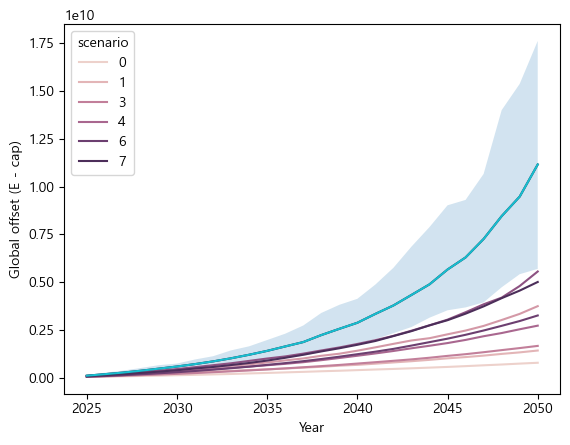

In [ ]:
# 시나리오별 carbon offset 글로벌 합산 및 연도별 평균
# (time, sim, scenario)
# E - cap 이기 때문에 E그래프와 유사한 모양새를 보임. -> 큰 차이 없음 
offset_global = offset.sum(axis=0)
offset_mean = offset_global.mean(axis=1)
# shape: (time, scenario)

import pandas as pd

years = np.arange(2025, 2051)

df_plot = (
    pd.DataFrame(offset_mean, index=years)
      .reset_index()
      .melt(id_vars="index", var_name="scenario", value_name="offset")
      .rename(columns={"index": "year"})
)
import seaborn as sns
import matplotlib.pyplot as plt
offset_q10 = np.quantile(offset_global, 0.10, axis=1)
offset_q90 = np.quantile(offset_global, 0.90, axis=1)


sns.lineplot(
    data=df_plot,
    x="year",
    y="offset",
    hue="scenario"
)
plt.plot(years, offset_mean[:, k])
plt.fill_between(years, offset_q10[:, k], offset_q90[:, k], alpha=0.2)

plt.xlabel("Year")
plt.ylabel("Global offset (E - cap)")
plt.show()


=== 탄소 상쇄 비용 도출 ===
EU ETS 역사적 데이터 기반 탄소가격 분포 가정
{'mu': 75, 'std': 7}

탄소가격 최소: 49.46111022349652
탄소가격 최대: 97.25197575557274
탄소가격 행렬: (26, 100)


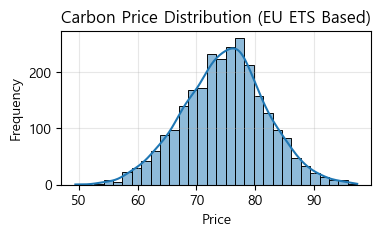

In [ ]:
# 탄소 상쇄 비용 도출 carbon offset cost
print('''=== 탄소 상쇄 비용 도출 ===''')
print('''EU ETS 역사적 데이터 기반 탄소가격 분포 가정''')
print(carbon)
# 탄소가격 난수화
rng = np.random.default_rng(42)
carbon_price = rng.normal(
    loc=carbon['mu'],
    scale=carbon['std'],
    size=(period, n_simulation)
)
carbon_price_ = carbon_price[:, :, None]  # (period, sim, 1)
print(f'''
탄소가격 최소: {carbon_price.min()}
탄소가격 최대: {carbon_price.max()}
탄소가격 행렬: {carbon_price.shape}''')
plt.figure(figsize=(4,2)), plt.grid(True, alpha=0.3)
plt.title("Carbon Price Distribution (EU ETS Based)"), plt.xlabel("Price"), plt.ylabel("Frequency")
_ = sns.histplot(carbon_price.reshape(-1), bins=30, kde=True)

In [181]:
# offset cost 계산
offset_cost = offset * carbon_price_
print(f'''
offset cost 행렬 - {offset_cost.shape}
offset cost 최소값 - {offset_cost.min()}
offset cost 최대값 - {offset_cost.max()}''')


offset cost 행렬 - (183, 26, 100, 9)
offset cost 최소값 - 0.0
offset cost 최대값 - 2567306036181.3276


## 그룹에 따른 variance reduction 실험
* 무작위 그룹 행렬 만들기

In [ ]:
# 목표 shape, 183, 20, 100
rng = np.random.default_rng(42)
X_rng = rng.uniform(
    loc=means,
    scale=stds,
    size=(country, period, n_simulation, len(means))
) 

Generator(PCG64) at 0x248EAB927A0

In [ ]:
# 그룹 배정 매트릭스 생성 함수
def make_random_grouping_matrix(
    n_countries: int = 183,
    max_group_size: int = 20,
    n_rep: int = 100,
    seed: int = 42,
) -> np.ndarray:
    """
    Returns
    -------
    G : np.ndarray, shape (n_countries, max_group_size, n_rep), dtype int16
        G[i, s-1, r] = group id of country i when group size = s, repetition = r.
        For each (s, r):
          - countries are randomly permuted
          - partitioned into floor(n/s) groups of size s
          - the remainder (n % s) countries are all put into ONE additional group (the last group id)
    """
    rng = np.random.default_rng(seed)
    G = np.full((n_countries, max_group_size, n_rep), -1, dtype=np.int16)

    for s in range(1, max_group_size + 1):
        full_groups = n_countries // s         # number of complete groups
        rem = n_countries % s                  # remainder size
        last_gid = full_groups                 # remainder group id (only used if rem>0)

        for r in range(n_rep):
            perm = rng.permutation(n_countries)  # 183 국가 행렬(183,)

            gid = np.full(n_countries, -1, dtype=np.int16)   # group id array

            # complete groups
            for g in range(full_groups):     
                members = perm[g*s:(g+1)*s]
                gid[members] = g

            # remainder -> one group
            if rem > 0:
                members = perm[full_groups*s:]
                gid[members] = last_gid

            G[:, s-1, r] = gid

    return G

# 예시 실행
group_arr = make_random_grouping_matrix()
print(group_arr.shape)          # (183, 20, 100)
print(group_arr[:, 0, 0].max()) # s=1이면 182 (각자 1명씩 그룹)
print(group_arr[:, 1, 0].max()) # s=2이면 91 (91개 완전그룹 + 잔여(1명)그룹 = 마지막 id 91)
print(group_arr.shape)

(183, 20, 100)
182
91
(183, 20, 100)


In [225]:
# 그룹 배정 결과 확인하기
# group_arr 로 그룹 행렬을 만들었습니다.
group_arr[:, 19, 0:6]   # G[국가, 그룹크기19(20명), 강건성 반복0~5]

array([[0, 0, 5, 5, 4, 3],
       [2, 2, 6, 2, 0, 8],
       [5, 0, 3, 4, 1, 6],
       ...,
       [2, 4, 2, 1, 8, 5],
       [1, 5, 1, 5, 2, 1],
       [5, 8, 0, 2, 7, 5]], dtype=int16)

In [229]:
# (country, sim, scenario)
offset_cost_final = offset_cost[:, -1, :, :]
print(f'''
offset cost 행렬 - {offset_cost_final.shape}
offset cost 최소값 - {offset_cost_final.min()}
offset cost 최대값 - {offset_cost_final.max()}''')


offset cost 행렬 - (183, 100, 9)
offset cost 최소값 - 0.0
offset cost 최대값 - 2567306036181.3276


## 중간 시각화
* 글로벌 offset cost

In [144]:
# 차트 그리기 위한 global offset cost 계산

offset_cost_global = offset_global * carbon_price_
print(offset_cost_global.shape)
print("min cost:", offset_cost_global.min())

(26, 100, 9)
min cost: 1228830460.3851883


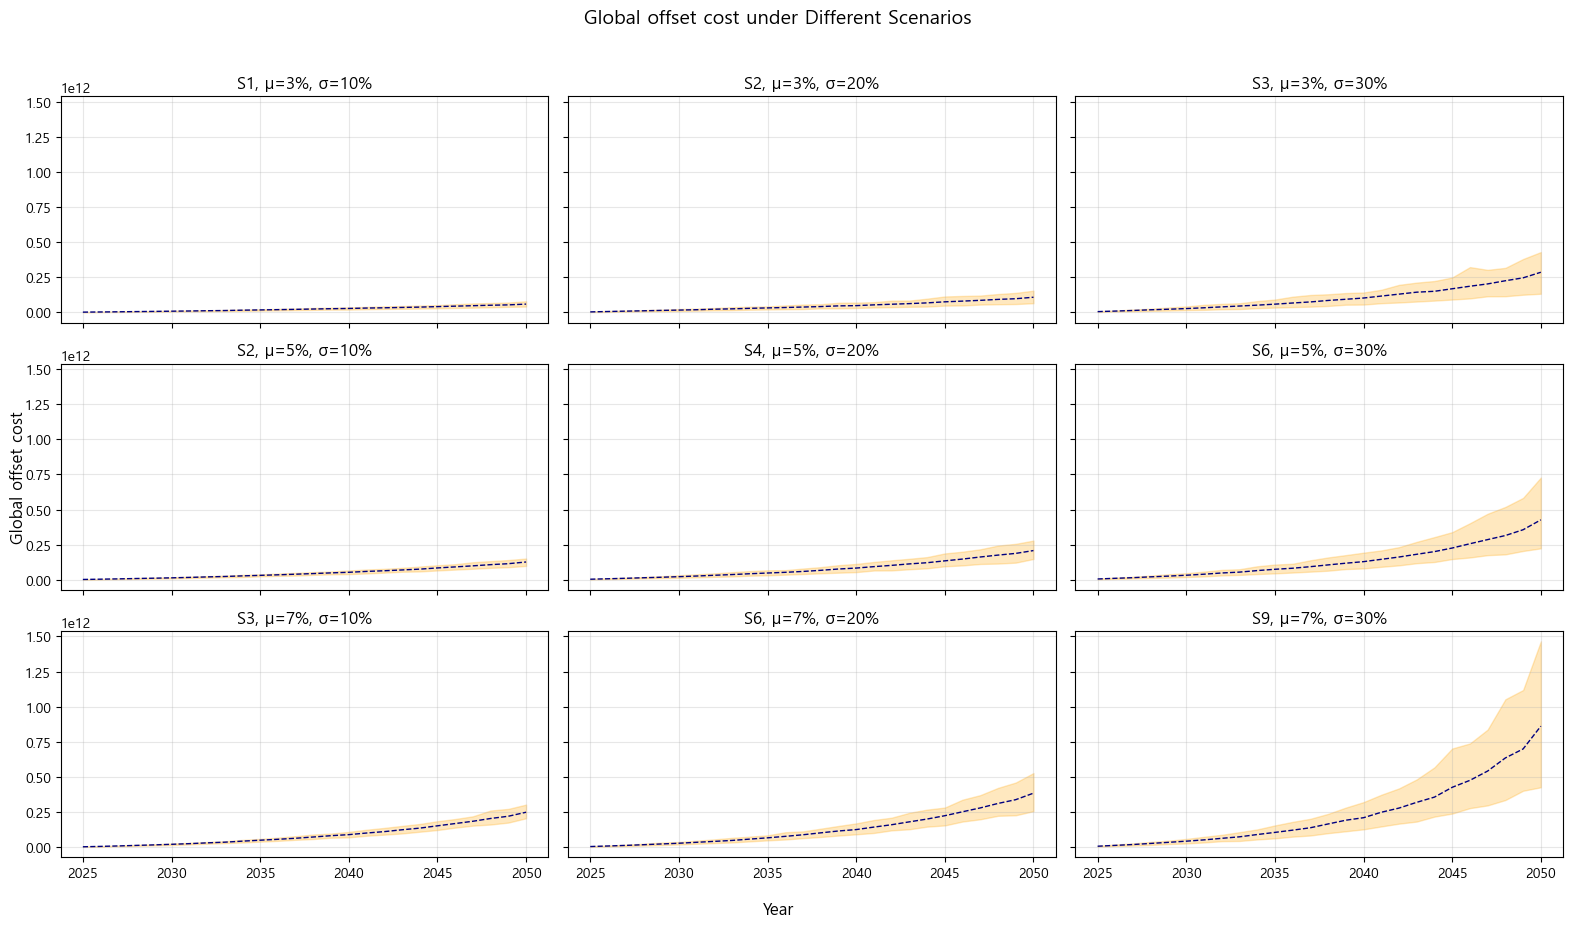

In [145]:
import matplotlib.pyplot as plt
import numpy as np

q_low, q_high = 0.10, 0.90

fig, axes = plt.subplots(3, 3, figsize=(16, 9), sharex=True, sharey=True)

for i, mu in enumerate(means):
    for j, sd in enumerate(stds):
        ax = axes[i, j]
        k = scen_idx(i, j)

        # (time, sim)
        cost_ts = offset_cost_global[:, :, k]

        # 연도별 요약
        cost_mean = cost_ts.mean(axis=1)
        cost_lo   = np.quantile(cost_ts, q_low,  axis=1)
        cost_hi   = np.quantile(cost_ts, q_high, axis=1)

        # 평균선
        ax.plot(
            years_sim,
            cost_mean,
            color="navy",
            linestyle="--",
            linewidth=1
        )

        # 불확실성 밴드
        ax.fill_between(
            years_sim,
            cost_lo,
            cost_hi,
            color="orange",
            alpha=0.25
        )

        ax.set_title(f"S{(i+1)*(j+1)}, μ={int(mu*100)}%, σ={int(sd*100)}%")
        ax.grid(True, alpha=0.3)

# 공통 라벨
fig.supxlabel("Year")
fig.supylabel("Global offset cost")
plt.tight_layout()
fig.suptitle(
    "Global offset cost under Different Scenarios",
    fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


* offset cost는 carbon Emission과 큰 차이 없음 

## offset cost final로부터 offset cost variance도출

In [232]:
offset_cost_final.shape  # (183, 100, 9)

(183, 100, 9)

In [247]:
import numpy as np
from tqdm import tqdm

N, MC, K = offset_cost_final.shape
_, S, R = group_arr.shape

ddof = 1
offset_cost_var = np.zeros((S, R, K), dtype=float)

for s_idx in tqdm(range(S), desc="group size"):
    for r in range(R):
        gid = group_arr[:, s_idx, r].astype(int)
        n_groups = gid.max() + 1

        # 그룹 크기 (n_groups,)
        group_sizes = np.bincount(gid, minlength=n_groups)

        for k in range(K):
            # (N, MC)
            costs = offset_cost_final[:, :, k]

            # (n_groups, MC): 그룹별 총비용
            group_sum = np.zeros((n_groups, MC), dtype=float)
            np.add.at(group_sum, gid, costs)

            # (n_groups, MC): 1인당 비용
            group_mean = group_sum / group_sizes[:, None]

            # (MC,): 각 MC에서 그룹 간 분산
            var_across_groups_each_mc = group_mean.var(axis=0, ddof=ddof)

            # MC 평균
            offset_cost_var[s_idx, r, k] = var_across_groups_each_mc.mean()


group size: 100%|██████████| 20/20 [00:03<00:00,  5.30it/s]


(20, 100, 9)
[1.51627890e+18 7.55876093e+17 4.80404452e+17 3.89486741e+17
 2.94356091e+17 2.35719571e+17 2.11388642e+17 1.81851982e+17
 1.68481779e+17 2.61331250e+17 1.30865955e+17 1.40139656e+17
 1.01946026e+17 1.45262248e+17 1.20109468e+17 1.07656751e+17
 9.54808667e+16 1.44903543e+17 1.35491973e+17 9.05366790e+16]


<Axes: >

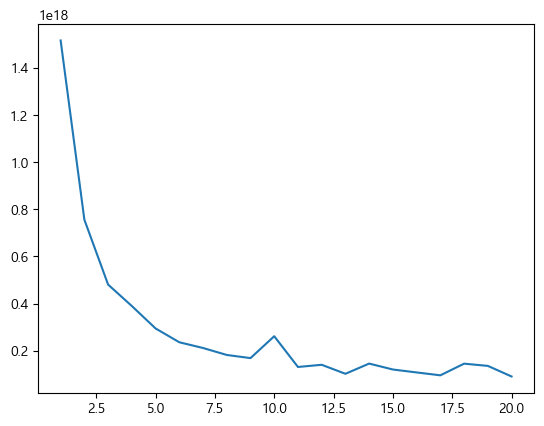

In [248]:
print(offset_cost_var.shape)  # (20, 100, 9)

# 예: r=0, scenario=0
print(offset_cost_var[:, 0, 0])
sns.lineplot(x=np.arange(1, 21), y=offset_cost_var[:, 0, 0])


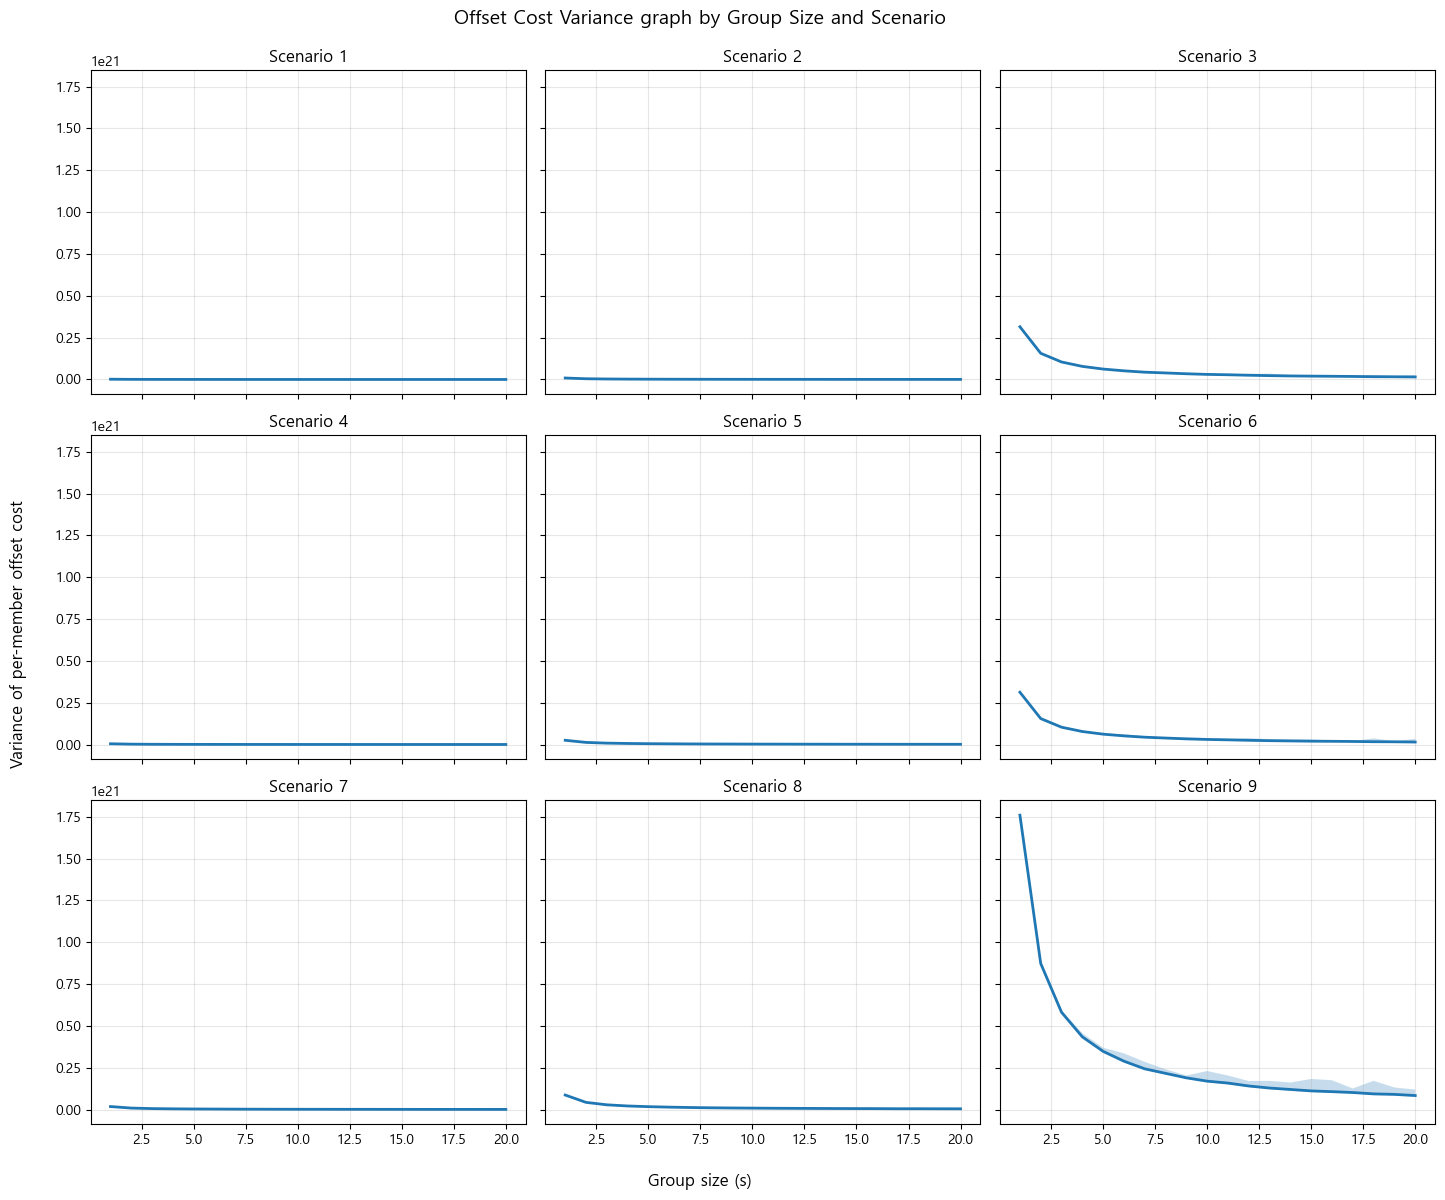

In [252]:
import numpy as np
import matplotlib.pyplot as plt

S, R, K = offset_cost_var.shape
x = np.arange(1, S + 1)   # s = 1..20

fig, axes = plt.subplots(3, 3, figsize=(15, 12), sharex=True, sharey=True)

for k in range(K):
    ax = axes[k // 3, k % 3]

    vals = offset_cost_var[:, :, k]   # (20, 100)

    q10 = np.quantile(vals, 0.10, axis=1)
    q50 = np.quantile(vals, 0.50, axis=1)
    q90 = np.quantile(vals, 0.90, axis=1)

    ax.fill_between(x, q10, q90, alpha=0.25)
    ax.plot(x, q50, linewidth=2)

    # ax.set_yscale("log")          # ✅ 로그 스케일
    ax.set_title(f"Scenario {k+1}")
    ax.grid(True, alpha=0.3)

# 공통 축 라벨
fig.text(0.5, 0.04, "Group size (s)", ha="center", fontsize=12)
fig.text(0.04, 0.5, "Variance of per-member offset cost", va="center",
         rotation="vertical", fontsize=12)

plt.tight_layout(rect=[0.06, 0.06, 1, 1])
fig.suptitle(
    "Offset Cost Variance graph by Group Size and Scenario",
    fontsize=14, y=1.02)
plt.show()

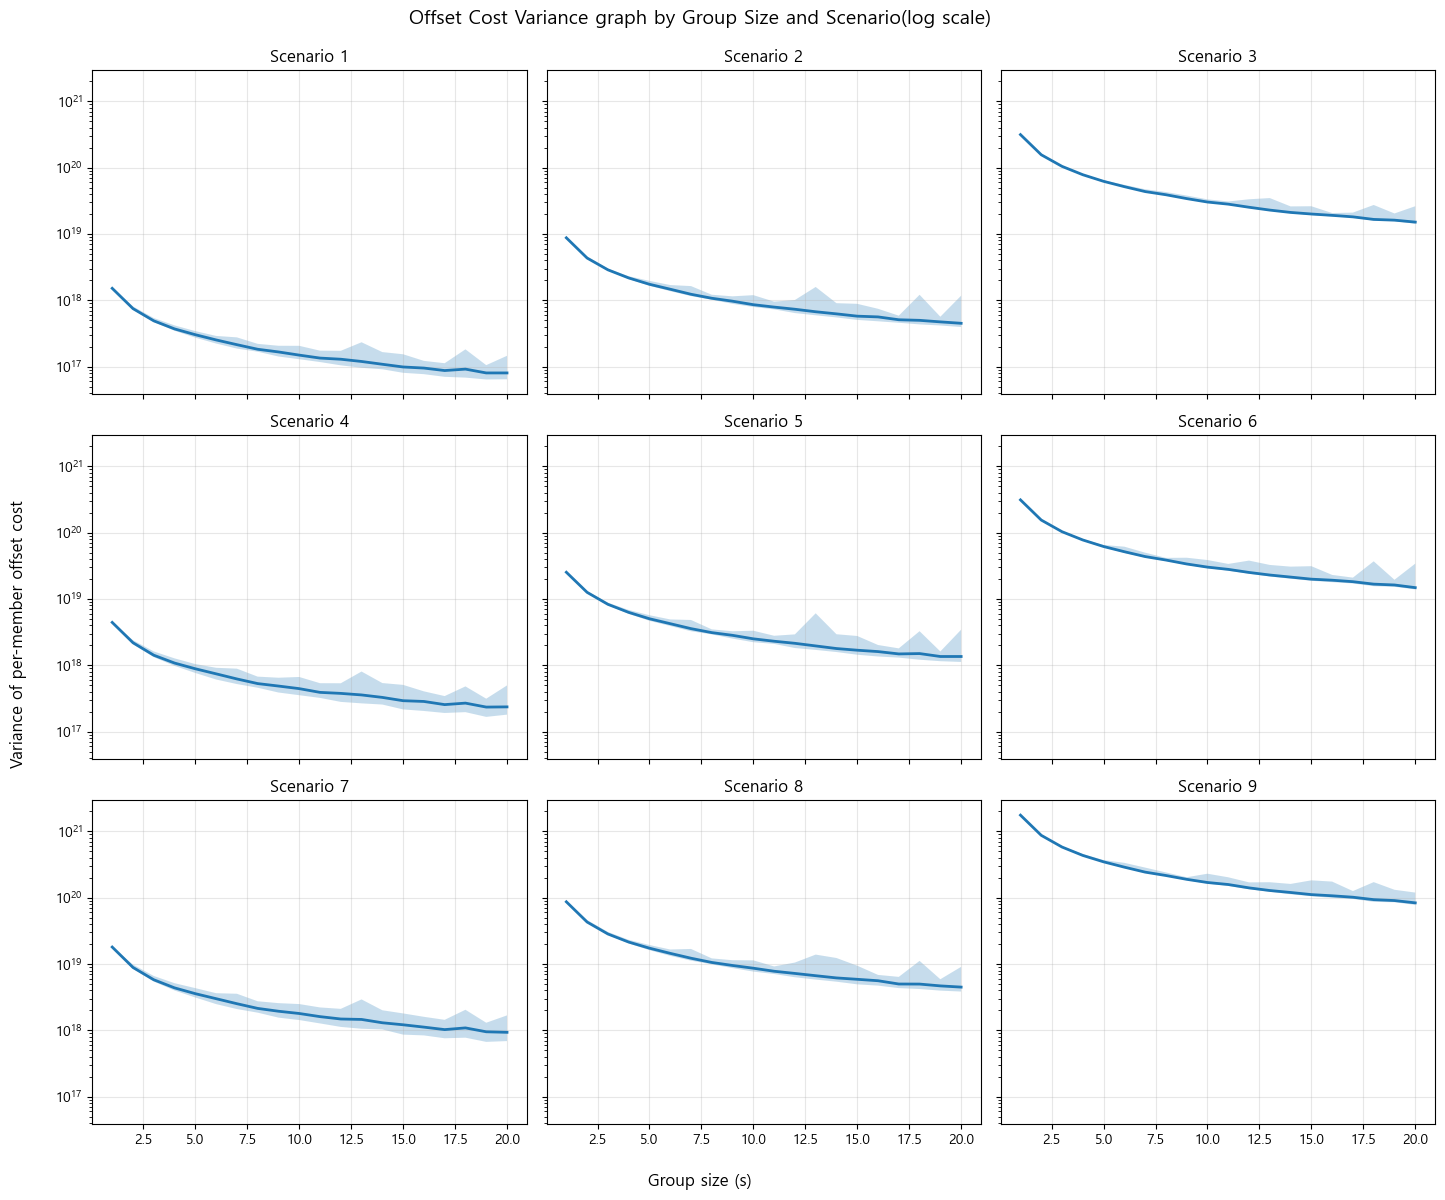

In [254]:
import numpy as np
import matplotlib.pyplot as plt

S, R, K = offset_cost_var.shape
x = np.arange(1, S + 1)   # s = 1..20

fig, axes = plt.subplots(3, 3, figsize=(15, 12), sharex=True, sharey=True)

for k in range(K):
    ax = axes[k // 3, k % 3]

    vals = offset_cost_var[:, :, k]   # (20, 100)

    q10 = np.quantile(vals, 0.10, axis=1)
    q50 = np.quantile(vals, 0.50, axis=1)
    q90 = np.quantile(vals, 0.90, axis=1)

    ax.fill_between(x, q10, q90, alpha=0.25)
    ax.plot(x, q50, linewidth=2)

    ax.set_yscale("log")          # ✅ 로그 스케일
    ax.set_title(f"Scenario {k+1}")
    ax.grid(True, alpha=0.3)

# 공통 축 라벨
fig.text(0.5, 0.04, "Group size (s)", ha="center", fontsize=12)
fig.text(0.04, 0.5, "Variance of per-member offset cost", va="center",
         rotation="vertical", fontsize=12)

plt.tight_layout(rect=[0.06, 0.06, 1, 1])
fig.suptitle(
    "Offset Cost Variance graph by Group Size and Scenario(log scale)",
    fontsize=14, y=1.02)
plt.show()